In [1]:
from galpy.df import eddingtondf
from galpy.potential import NFWPotential, PlummerPotential, HernquistPotential
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from ezfalcon.simulation import Sim

In [2]:
hostpot = NFWPotential(mvir=4, conc=10)
hostpot.turn_physical_on()

In [59]:
dmpot = NFWPotential(amp=1e10 * u.Msun, a=10*u.kpc)
dmpot.turn_physical_on()
# stellarpot = PlummerPotential(amp=1e9 * u.Msun, b=0.5*u.kpc)
# stellarpot.turn_physical_on()

In [60]:
dmpot.conc()

np.float64(7.080413262383992)

In [61]:
rcutoff = 20#dmpot.rvir()#hostpot.rtide(R=20*u.kpc, z=5 * u.kpc,  M = dmpot.mass(dmpot.rvir())*u.Msun)# dmpot.rvir()#
# mdm = dmpot.mass(rcutoff*u.kpc)

In [62]:
ndm = 5_000

In [63]:
progpot = dmpot
dmdf = eddingtondf(pot=progpot, denspot=dmpot, rmax=rcutoff*u.kpc)

#dm_sample = dmdf.sample(n=ndm)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/potential/TwoPowerSphericalPotential.py:182: RuntimeWarning: invalid value encountered in scalar multiply
  -self._amp



In [64]:
from scipy.integrate import cumulative_trapezoid

def mass_funct(r, df):
    """Return enclosed mass M(<r) from vmomentdensity."""
    r_kpc = np.atleast_1d(u.Quantity(r, u.kpc).to_value(u.kpc))
    rho = []
    for ri in r_kpc:
        rhoi = df.vmomentdensity(ri * u.kpc, 0, 0)
        if hasattr(rhoi, "to_value"):
            rhoi = rhoi.to_value(u.Msun / u.kpc**3)
        rho.append(float(rhoi))
    rho = np.asarray(rho, dtype=float)

    # Stabilize occasional non-finite values from df.vmomentdensity at tiny radii.
    finite = np.isfinite(rho)
    if not np.any(finite):
        raise ValueError("vmomentdensity returned no finite values on this radius grid.")
    if not np.all(finite):
        idx = np.flatnonzero(finite)
        rho = np.interp(np.arange(len(rho)), idx, rho[idx])

    shell = 4.0 * np.pi * rho * r_kpc**2
    return cumulative_trapezoid(shell, r_kpc, initial=0.0)

In [65]:
from scipy.interpolate import PchipInterpolator

# Evaluate vmomentdensity on a coarse grid for speed, then interpolate to a dense grid for smoothness.
r_eval = np.geomspace(1e-2, rcutoff, 34)
rho_eval = np.array([dmdf.vmomentdensity(ri * u.kpc, 0, 0) for ri in r_eval], dtype=float)

# Replace non-finite samples and enforce positivity for log-space interpolation.
finite = np.isfinite(rho_eval)
if not np.any(finite):
    raise ValueError("vmomentdensity returned no finite values on the evaluation grid.")
if not np.all(finite):
    idx = np.flatnonzero(finite)
    rho_eval = np.interp(np.arange(len(rho_eval)), idx, rho_eval[idx])
rho_eval = np.clip(rho_eval, 1e-300, None)

# Dense grid used for integration and plotting (must stay within r_eval range).
rlist = np.geomspace(1e-2, rcutoff, 140) * u.kpc
rho_spline = PchipInterpolator(np.log(r_eval), np.log(rho_eval), extrapolate=False)
rho_dense = np.exp(rho_spline(np.log(rlist.to_value(u.kpc))))

# If interpolation still produces edge NaNs, fill them from nearest finite values.
finite_dense = np.isfinite(rho_dense)
if not np.any(finite_dense):
    raise ValueError("Interpolated density is non-finite on the dense grid.")
if not np.all(finite_dense):
    idx = np.flatnonzero(finite_dense)
    rho_dense = np.interp(np.arange(len(rho_dense)), idx, rho_dense[idx])

shell = 4.0 * np.pi * rho_dense * rlist.to_value(u.kpc)**2
encmass = cumulative_trapezoid(shell, rlist.to_value(u.kpc), initial=0.0)

# Guard against tiny numerical non-monotonicity in the CDF input.
encmass = np.maximum.accumulate(encmass)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:183: RuntimeWarning: invalid value encountered in sqrt
  / numpy.sqrt(_evaluatePotentials(pot, r, 0) - E)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:139: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integrate.quad(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:139: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance fr

Text(0, 0.5, 'Mass(Msun)')

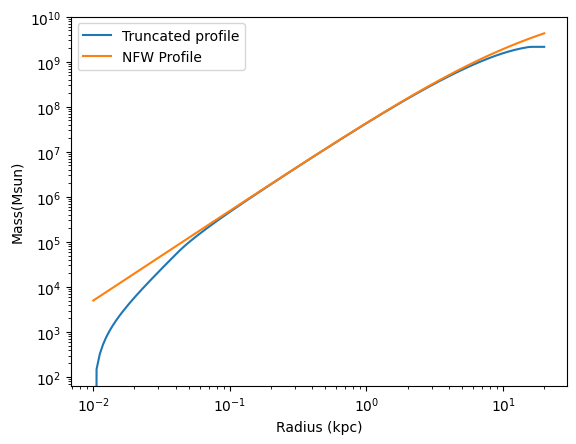

In [66]:
plt.plot(rlist, encmass, label="Truncated profile")
plt.plot(rlist, dmpot.mass(rlist, use_physical=True), label="NFW Profile")
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel("Radius (kpc)")
plt.ylabel("Mass(Msun)")

In [67]:
import numpy as np
from scipy.interpolate import PchipInterpolator

# Build inverse CDF directly from vmomentdensity-derived enclosed mass.
r = rlist
M = encmass
F = M / M[-1]
valid = np.isfinite(F)
F = F[valid]
r_vals = r.to_value(u.kpc)[valid]

# Keep only strictly increasing CDF points for interpolation stability.
mask = np.concatenate(([True], np.diff(F) > 1e-14))
if np.sum(mask) < 2:
    raise ValueError("CDF is not strictly increasing; rerun Cell 8 or adjust grid/smoothing.")
F_strict = F[mask]
r_strict = r_vals[mask]
Finv = PchipInterpolator(F_strict, r_strict, extrapolate=False)

# Sample radii.

u_rand = np.random.random(ndm)
rsamp = Finv(u_rand)

# Isotropic angles -> Cartesian
cos_th = 2 * np.random.random(ndm) - 1
phi = 2 * np.pi * np.random.random(ndm)
sin_th = np.sqrt(1 - cos_th**2)
x = rsamp * sin_th * np.cos(phi)
y = rsamp * sin_th * np.sin(phi)
z = rsamp * cos_th

In [68]:
from ezfalcon.tools import galpy_orbit_to_ezfalcon
o_samp = dmdf.sample(R=np.sqrt(x**2 + y**2)*u.kpc, phi=np.arctan2(y, x)*u.rad, z=z*u.kpc)
pos_sample, vel_sample = galpy_orbit_to_ezfalcon(o_samp)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:181: RuntimeWarning: divide by zero encountered in scalar divide
  (Fr * d2nudr2(r) + dnudr(r) * evaluateR2derivs(pot, r, 0, use_physical=False))



In [69]:
sim = Sim()
sim.add_particles('dm', pos=pos_sample, vel=vel_sample, mass=np.repeat(encmass[-1]/ndm, ndm))

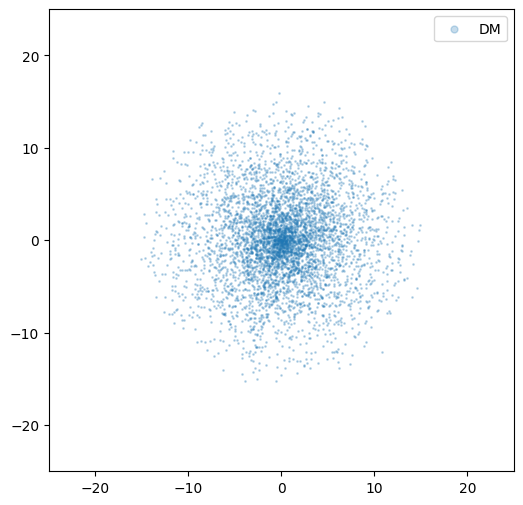

In [70]:
plt.figure(figsize=(6, 6))
plt.scatter(sim.dm.x(0), sim.dm.y(0), s=1, alpha=0.25, label='DM')

plt.xlim(-25, 25)
plt.ylim(-25, 25)
plt.legend(markerscale=5)

Text(0, 0.5, 'Number of particles')

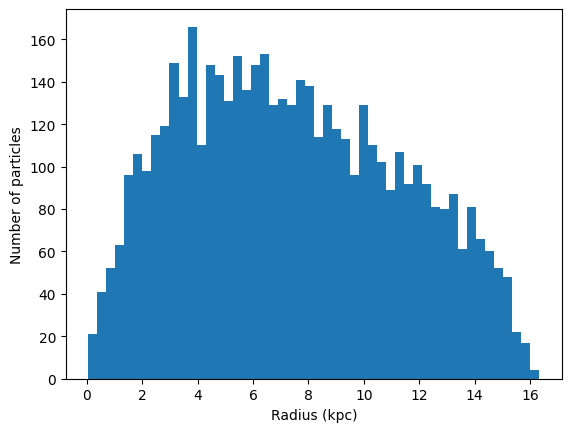

In [71]:
plt.hist(sim.r(0), bins=50)
plt.xlabel("Radius (kpc)")
plt.ylabel("Number of particles")

# Run Simulation

In [88]:
sim.run(2.0, dt=0.0001, dt_out=0.01, eps=0.1)

100%|██████████| 20000/20000 [03:07<00:00, 106.63it/s]


/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1049: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



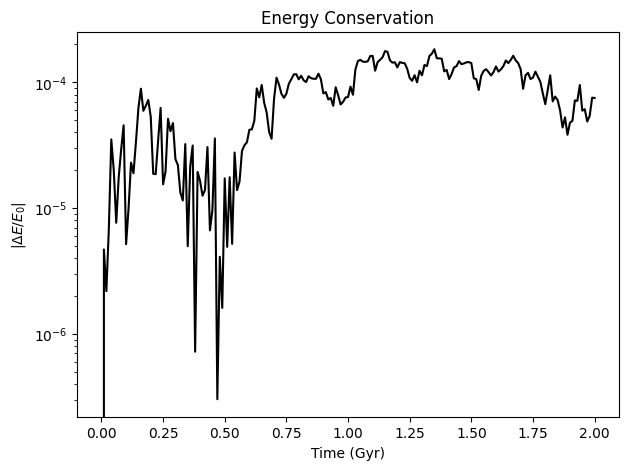

In [93]:
sim.plot_energy_diagnostic()

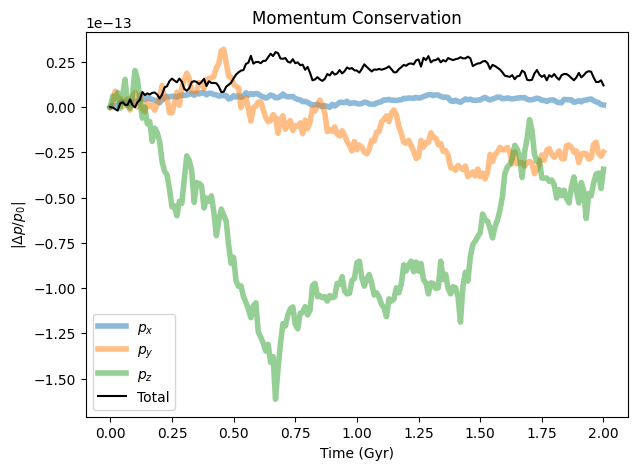

In [94]:
sim.plot_momentum_diagnostic()

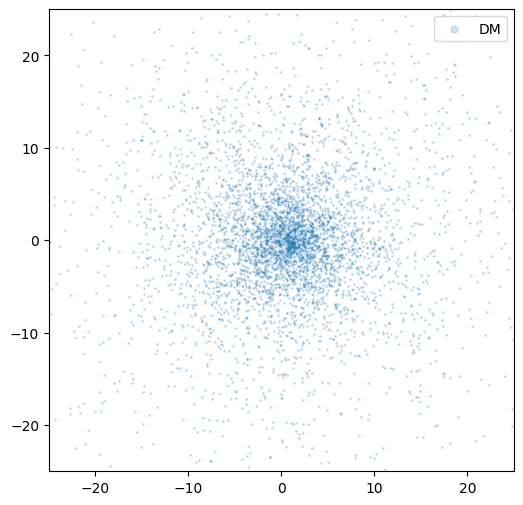

In [95]:
plt.figure(figsize=(6, 6))
plt.scatter(sim.dm.x(-1), sim.dm.y(-1), s=1, alpha=0.2, label='DM')

plt.xlim(-25, 25)
plt.ylim(-25, 25)
plt.legend(markerscale=5)

In [96]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())//2  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
dm_sc = ax_anim.scatter(sim.dm.x(0), sim.dm.y(0), s=1, c='k', alpha=0.2)
ax_anim.set_xlim(-25, 25)
ax_anim.set_ylim(-25, 25)
ax_anim.set_xlabel('x [kpc]', fontsize=20)
ax_anim.set_ylabel('y [kpc]', fontsize=20)
ax_anim.set_aspect('equal')
title = ax_anim.set_title('t = 0', fontsize=22)

def update(i):
    i *= 2
    dm_sc.set_offsets(list(zip(sim.dm.x(i), sim.dm.y(i))))
    title.set_text(f't = {sim.times[i]:.2f} Gyr')
    return dm_sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=100, blit=False)
plt.close(fig_anim)
fig_anim.tight_layout()
anim.save(
    'nfw_evolution_2.gif',
    writer='pillow',
    fps=15
)